# Customer Segmentation — Unsupervised Learning Suite

**Business Problem:**  
An e-commerce retailer wants to understand its customer base and design targeted marketing strategies. Instead of treating all customers the same, we identify distinct behavioral segments using unsupervised learning on transactional data.

**Approach:**  
We engineer RFM (Recency, Frequency, Monetary) features from raw transaction history, apply and compare three clustering algorithms (K-Means, Hierarchical, DBSCAN), reduce dimensionality for visualization (PCA, t-SNE), and profile each segment with actionable business recommendations.

**Dataset:**  
UK-based online retail transactions — 2010 to 2011. Source: UCI Machine Learning Repository via Kaggle.

**Tech Stack:**  
Python · Pandas · Scikit-learn · Scipy · Matplotlib · Seaborn · Plotly · MLflow · FastAPI · Docker

In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

import joblib
import os

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries loaded.")

Libraries loaded.


## 1. Data Loading & Initial Inspection

We load the dataset and immediately check its shape, dtypes, and a few rows to understand what we're working with before touching anything.

In [23]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

print("Shape:", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Shape: (541909, 8)

Column dtypes:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,17850.000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,17850.000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,17850.000,United Kingdom


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 2. Exploratory Data Analysis

Before engineering features, we need to understand the data's structure, quality, and distributions. Every cleaning decision is made here with explicit justification.

In [25]:
print(f"Total transactions: {df.shape[0]:,}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique invoices: {df['InvoiceNo'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Missing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Total transactions: 541,909
Date range: 1/10/2011 10:04 to 9/9/2011 9:52
Unique customers: 4,372
Unique invoices: 25,900
Unique products: 4,070
Countries: 38

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing percentage:
InvoiceNo      0.000
StockCode      0.000
Description    0.270
Quantity       0.000
InvoiceDate    0.000
UnitPrice      0.000
CustomerID    24.930
Country        0.000
dtype: float64


### 2.1 Data Cleaning

We handle four issues in sequence: missing values, cancelled orders, dtype corrections, and invalid quantity/price values. Each step is documented with the business reason for the decision.

In [26]:
print(f"Starting shape: {df.shape}")

# Drop missing descriptions — too few to matter, no way to infer
df = df.dropna(subset=['Description'])
print(f"After dropping missing descriptions: {df.shape}")

# Drop missing CustomerID — guest transactions, cannot be attributed to any customer
df = df.dropna(subset=['CustomerID'])
print(f"After dropping missing CustomerID: {df.shape}")

# Remove cancelled orders — InvoiceNo starting with 'C' are returns/cancellations
cancelled_mask = df['InvoiceNo'].astype(str).str.startswith('C')
print(f"Cancelled transactions found: {cancelled_mask.sum():,}")
df = df[~cancelled_mask]
print(f"After removing cancellations: {df.shape}")

# Fix dtypes
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Remove rows with zero or negative Quantity and UnitPrice
# Negative quantity outside of cancellations = data error
# Zero or negative price = data error, not a real transaction
print(f"\nRows with Quantity <= 0: {(df['Quantity'] <= 0).sum():,}")
print(f"Rows with UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum():,}")

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f"\nFinal clean shape: {df.shape}")

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"\nDate range after cleaning: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers remaining: {df['CustomerID'].nunique():,}")

Starting shape: (541909, 8)
After dropping missing descriptions: (540455, 8)
After dropping missing CustomerID: (406829, 8)
Cancelled transactions found: 8,905
After removing cancellations: (397924, 8)

Rows with Quantity <= 0: 0
Rows with UnitPrice <= 0: 40

Final clean shape: (397884, 8)

Date range after cleaning: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers remaining: 4,338


### 2.2 Distributions & Business Patterns

We examine transaction distributions, revenue over time, and country-level concentration to extract preliminary business insights before moving to feature engineering.

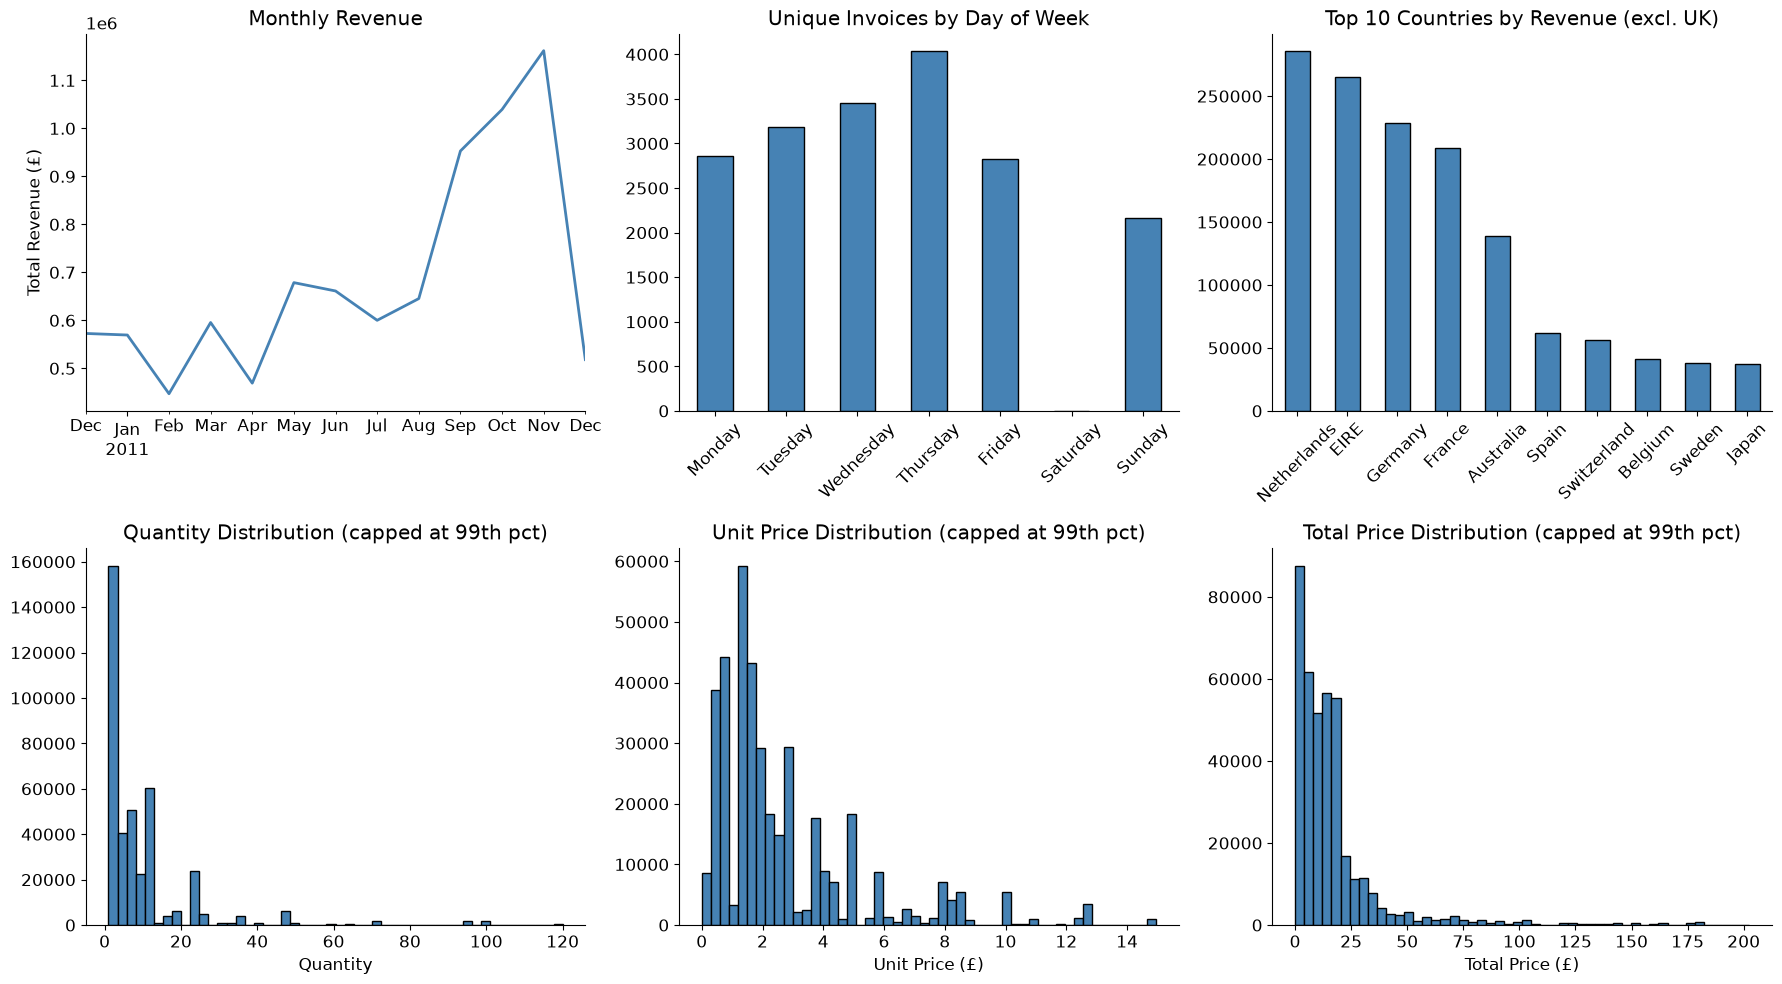

UK revenue share: 82.0%
Top 5 countries: ['United Kingdom', 'Netherlands', 'EIRE', 'Germany', 'France']
Total revenue: £8,911,408

Top 5 products revenue share: 6.5%
Top 5 products: ['PAPER CRAFT , LITTLE BIRDIE', 'REGENCY CAKESTAND 3 TIER', 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'MEDIUM CERAMIC TOP STORAGE JAR']


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Transaction volume over time
df.set_index('InvoiceDate')['TotalPrice'].resample('M').sum().plot(
    ax=axes[0,0], color='steelblue', linewidth=2
)
axes[0,0].set_title('Monthly Revenue')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Total Revenue (£)')

# Transactions by day of week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(day_order)
day_counts.plot(kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Unique Invoices by Day of Week')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)

# Top 10 countries by revenue excluding UK
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_revenue_ex_uk = country_revenue.drop('United Kingdom').head(10)
country_revenue_ex_uk.plot(kind='bar', ax=axes[0,2], color='steelblue', edgecolor='black')
axes[0,2].set_title('Top 10 Countries by Revenue (excl. UK)')
axes[0,2].set_xlabel('')
axes[0,2].tick_params(axis='x', rotation=45)

# Quantity distribution (capped at 99th percentile for readability)
q99 = df['Quantity'].quantile(0.99)
axes[1,0].hist(df[df['Quantity'] <= q99]['Quantity'], bins=50, 
               color='steelblue', edgecolor='black')
axes[1,0].set_title('Quantity Distribution (capped at 99th pct)')
axes[1,0].set_xlabel('Quantity')

# UnitPrice distribution (capped at 99th percentile)
p99 = df['UnitPrice'].quantile(0.99)
axes[1,1].hist(df[df['UnitPrice'] <= p99]['UnitPrice'], bins=50,
               color='steelblue', edgecolor='black')
axes[1,1].set_title('Unit Price Distribution (capped at 99th pct)')
axes[1,1].set_xlabel('Unit Price (£)')

# TotalPrice distribution (capped at 99th percentile)
t99 = df['TotalPrice'].quantile(0.99)
axes[1,2].hist(df[df['TotalPrice'] <= t99]['TotalPrice'], bins=50,
               color='steelblue', edgecolor='black')
axes[1,2].set_title('Total Price Distribution (capped at 99th pct)')
axes[1,2].set_xlabel('Total Price (£)')

plt.tight_layout()
plt.show()

# Business summary stats
uk_revenue = country_revenue['United Kingdom']
total_revenue = country_revenue.sum()
print(f"UK revenue share: {uk_revenue/total_revenue*100:.1f}%")
print(f"Top 5 countries: {list(country_revenue.head(5).index)}")
print(f"Total revenue: £{total_revenue:,.0f}")

top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)
top5_revenue = top_products.head(5).sum()
print(f"\nTop 5 products revenue share: {top5_revenue/total_revenue*100:.1f}%")
print(f"Top 5 products: {list(top_products.head(5).index)}")

### 2.3 Key EDA Findings

- Dataset spans December 2010 to December 2011 — exactly one year of transactions
- 82% of revenue originates from the United Kingdom; Netherlands and EIRE are the only notable international markets
- Revenue shows clear seasonality — spike in Q4 2011, consistent with holiday gifting behavior
- Product catalog is long-tail — top 5 products contribute only 6.5% of total revenue, meaning no single SKU dominates
- Quantity and UnitPrice distributions are heavily right-skewed — a small number of bulk orders drive the upper tail
- Thursday and Tuesday are peak transaction days; Sunday has near-zero activity (business is closed)

## 3. RFM Feature Engineering

RFM transforms raw transaction history into a customer-level behavioral profile using three metrics:

- **Recency**: How recently did the customer purchase? Measured as days since last invoice relative to a reference date. Lower is better — a customer who bought yesterday is more engaged than one who bought 6 months ago.
- **Frequency**: How often does the customer purchase? Measured as number of unique invoices. Higher means more loyal.
- **Monetary**: How much has the customer spent in total? Measured as sum of TotalPrice across all transactions.

Reference date is set to December 10, 2011 — one day after the last transaction in the dataset. This ensures the most recent customer gets a recency of 1, not 0, and all recency values are positive.

In [28]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM dataframe shape: {rfm.shape}")
print(f"\nRFM summary statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

print(f"\nCustomers with Monetary <= 0: {(rfm['Monetary'] <= 0).sum()}")

Reference date: 2011-12-10

RFM dataframe shape: (4338, 4)

RFM summary statistics:
       Recency  Frequency   Monetary
count 4338.000   4338.000   4338.000
mean    92.540      4.270   2054.270
std    100.010      7.700   8989.230
min      1.000      1.000      3.750
25%     18.000      1.000    307.410
50%     51.000      2.000    674.480
75%    142.000      5.000   1661.740
max    374.000    209.000 280206.020

Customers with Monetary <= 0: 0


### 3.1 RFM Distribution Analysis

RFM distributions are almost always right-skewed in transactional data — a small number of high-value, high-frequency customers pull the tail. We visualize raw and log-transformed distributions to confirm skewness and justify our preprocessing choices.

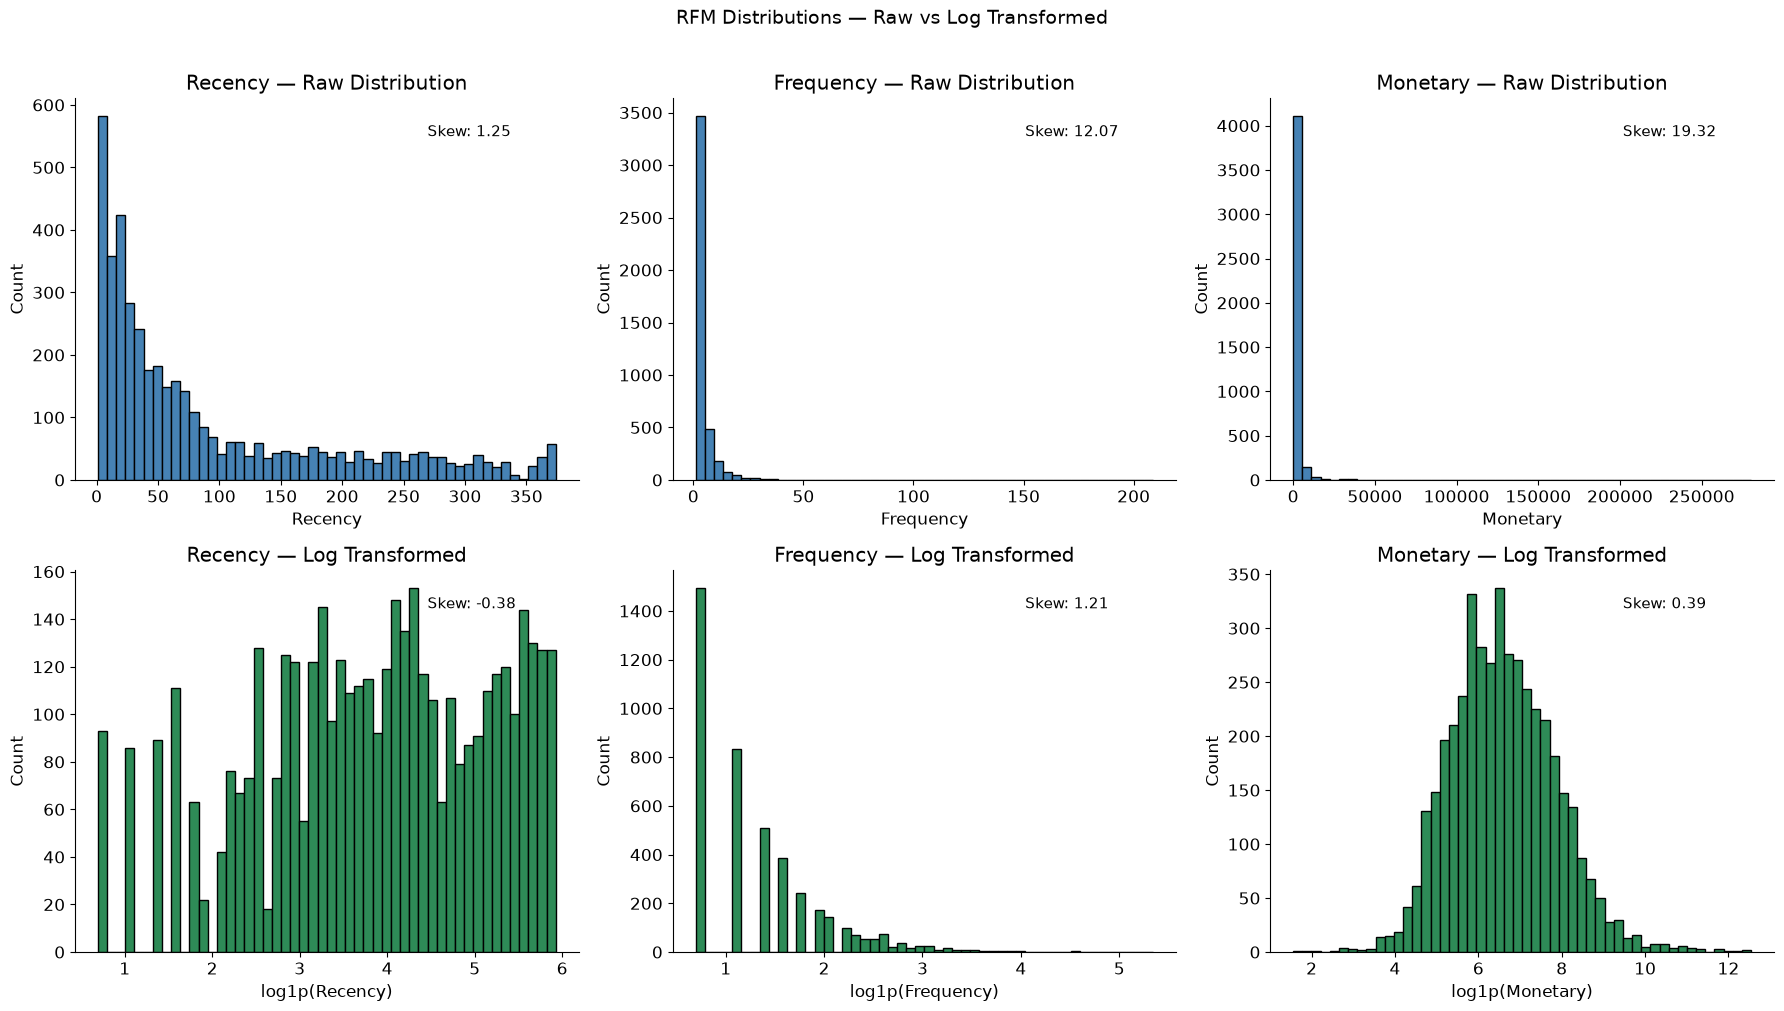

Skewness before log transform:
  Recency: 1.246
  Frequency: 12.067
  Monetary: 19.325

Skewness after log transform:
  Recency: -0.379
  Frequency: 1.209
  Monetary: 0.394


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(metrics):
    # Raw distribution
    axes[0, i].hist(rfm[col], bins=50, color='steelblue', edgecolor='black')
    axes[0, i].set_title(f'{col} — Raw Distribution')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    skew_val = rfm[col].skew()
    axes[0, i].text(0.7, 0.9, f'Skew: {skew_val:.2f}',
                    transform=axes[0, i].transAxes, fontsize=11)

    # Log transformed distribution
    axes[1, i].hist(np.log1p(rfm[col]), bins=50, color='seagreen', edgecolor='black')
    axes[1, i].set_title(f'{col} — Log Transformed')
    axes[1, i].set_xlabel(f'log1p({col})')
    axes[1, i].set_ylabel('Count')
    log_skew = np.log1p(rfm[col]).skew()
    axes[1, i].text(0.7, 0.9, f'Skew: {log_skew:.2f}',
                    transform=axes[1, i].transAxes, fontsize=11)

plt.suptitle('RFM Distributions — Raw vs Log Transformed', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Skewness before log transform:")
for col in metrics:
    print(f"  {col}: {rfm[col].skew():.3f}")

print("\nSkewness after log transform:")
for col in metrics:
    print(f"  {col}: {np.log1p(rfm[col]).skew():.3f}")

### 3.2 Additional Features

Beyond raw RFM, we engineer two additional customer-level features that add signal for clustering. AvgOrderValue captures spending efficiency — how much a customer spends per visit. CustomerLifetime captures engagement duration — how long they have been active.

In [30]:
# Average order value — spending per visit
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Customer lifetime — days between first and last purchase
customer_dates = df.groupby('CustomerID').agg(
    FirstPurchase = ('InvoiceDate', 'min'),
    LastPurchase  = ('InvoiceDate', 'max')
)
customer_dates['CustomerLifetime'] = (
    customer_dates['LastPurchase'] - customer_dates['FirstPurchase']
).dt.days

rfm = rfm.merge(customer_dates[['CustomerLifetime']], on='CustomerID')

print("RFM + engineered features:")
print(rfm.describe().round(2))
print(f"\nCustomers with CustomerLifetime = 0: {(rfm['CustomerLifetime'] == 0).sum()}")
print("(These are one-time buyers — first and last purchase on the same day)")

RFM + engineered features:
       Recency  Frequency   Monetary  AvgOrderValue  CustomerLifetime
count 4338.000   4338.000   4338.000       4338.000          4338.000
mean    92.540      4.270   2054.270        419.170           130.450
std    100.010      7.700   8989.230       1796.540           132.040
min      1.000      1.000      3.750          3.450             0.000
25%     18.000      1.000    307.410        178.620             0.000
50%     51.000      2.000    674.480        293.900            92.500
75%    142.000      5.000   1661.740        430.110           251.750
max    374.000    209.000 280206.020      84236.250           373.000

Customers with CustomerLifetime = 0: 1555
(These are one-time buyers — first and last purchase on the same day)


## 4. Preprocessing Pipeline

Clustering algorithms are distance-based. Features on different scales will produce meaningless distances — a £280,000 difference in Monetary completely dominates a 374-day difference in Recency. We apply three steps in sequence:

1. Winsorize at 99th percentile to cap extreme outliers
2. Log transform (log1p) to fix right skew in all features
3. RobustScaler to center and scale using median and IQR, resistant to remaining outliers

We use RobustScaler over StandardScaler because RFM data retains outlier influence even after log transform, and RobustScaler's use of median and IQR makes it robust to this.

In [31]:
features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'CustomerLifetime']

rfm_model = rfm[features].copy()

# Step 1 — Winsorize at 99th percentile
for col in features:
    upper = rfm_model[col].quantile(0.99)
    rfm_model[col] = rfm_model[col].clip(upper=upper)
    print(f"{col} — capped at {upper:.2f}")

print(f"\nAfter winsorizing:")
print(rfm_model.describe().round(2))

Recency — capped at 369.00
Frequency — capped at 30.00
Monetary — capped at 19881.00
AvgOrderValue — capped at 2031.16
CustomerLifetime — capped at 367.00

After winsorizing:
       Recency  Frequency  Monetary  AvgOrderValue  CustomerLifetime
count 4338.000   4338.000  4338.000       4338.000          4338.000
mean    92.500      4.010  1598.580        365.580           130.420
std     99.910      4.860  2797.830        313.620           131.990
min      1.000      1.000     3.750          3.450             0.000
25%     18.000      1.000   307.410        178.620             0.000
50%     51.000      2.000   674.480        293.900            92.500
75%    142.000      5.000  1661.740        430.110           251.750
max    369.000     30.000 19881.000       2031.160           367.000


In [32]:
# Step 2 — Log transform
rfm_log = np.log1p(rfm_model)

print("Skewness after log transform:")
print(rfm_log.skew().round(3))

# Step 3 — RobustScaler
scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)

print("\nScaled data summary:")
print(rfm_scaled.describe().round(3))

# Save the scaler for the API later
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.joblib')
print("\nScaler saved to ../models/scaler.joblib")

Skewness after log transform:
Recency            -0.380
Frequency           1.004
Monetary            0.201
AvgOrderValue      -0.163
CustomerLifetime   -0.394
dtype: float64

Scaled data summary:
       Recency  Frequency  Monetary  AvgOrderValue  CustomerLifetime
count 4338.000   4338.000  4338.000       4338.000          4338.000
mean    -0.060      0.220     0.041         -0.048            -0.234
std      0.664      0.605     0.729          0.822             0.457
min     -1.614     -0.369    -2.942         -4.790            -0.820
25%     -0.499     -0.369    -0.465         -0.566            -0.820
50%      0.000      0.000     0.000         -0.000             0.000
75%      0.501      0.631     0.535          0.434             0.180
max      0.972      2.126     2.007          2.205             0.248

Scaler saved to ../models/scaler.joblib


## 5. K-Means Clustering

K-Means partitions customers into K groups by minimizing Within Cluster Sum of Squares (WCSS) — the total squared distance between each point and its cluster centroid. We use two methods to find the optimal K: the elbow method (compactness) and silhouette analysis (separation quality).

In [33]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    print(f"K={k} | WCSS: {kmeans.inertia_:.2f} | Silhouette: {silhouette_scores[-1]:.4f}")

K=2 | WCSS: 5842.00 | Silhouette: 0.3402
K=3 | WCSS: 4598.43 | Silhouette: 0.2808
K=4 | WCSS: 3770.38 | Silhouette: 0.2794
K=5 | WCSS: 3258.11 | Silhouette: 0.2805
K=6 | WCSS: 2943.42 | Silhouette: 0.2730
K=7 | WCSS: 2668.15 | Silhouette: 0.2810
K=8 | WCSS: 2456.95 | Silhouette: 0.2736
K=9 | WCSS: 2259.02 | Silhouette: 0.2701
K=10 | WCSS: 2100.99 | Silhouette: 0.2701


### 5.1 Optimal K Selection

The elbow method shows the sharpest WCSS reduction up to K=4, after which gains diminish. Silhouette scores are moderate across all K values — expected for behavioral data which exists on a continuum rather than in discrete groups. K=4 balances statistical compactness with business interpretability.

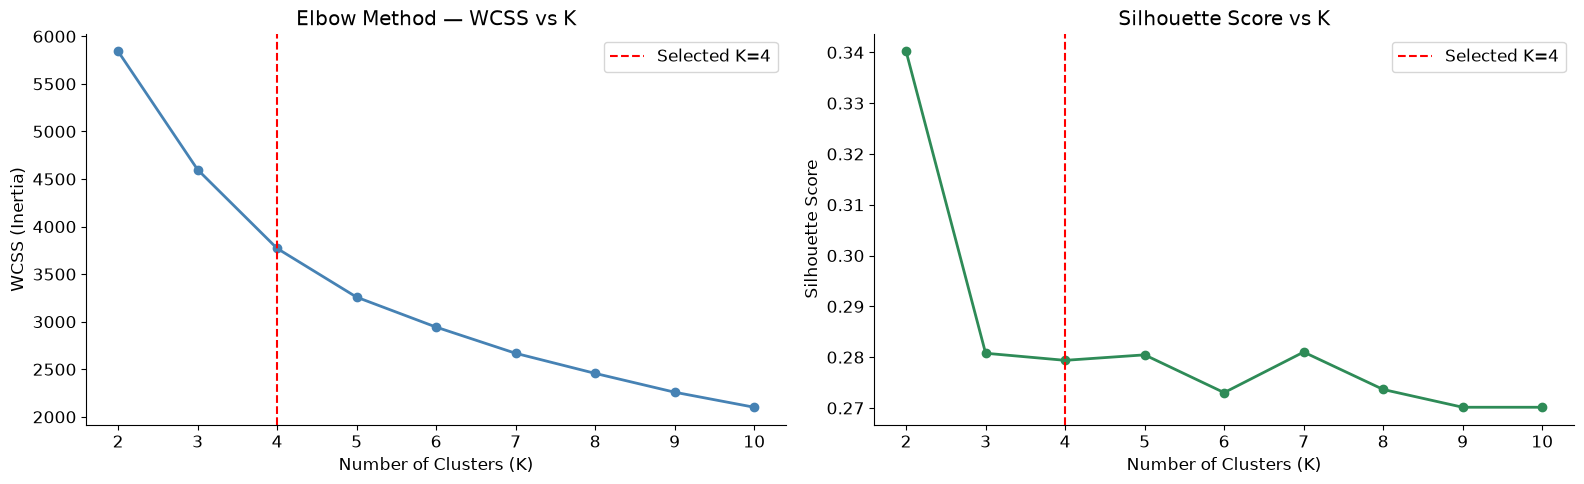

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow curve
axes[0].plot(K_range, wcss, marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Selected K=4')
axes[0].set_title('Elbow Method — WCSS vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].legend()

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, color='seagreen')
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Selected K=4')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
rfm['KMeans_Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print("K-Means cluster distribution:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())
print()
print(f"Silhouette score (K=4): {silhouette_score(rfm_scaled, rfm['KMeans_Cluster']):.4f}")

K-Means cluster distribution:
KMeans_Cluster
0     951
1    1058
2    1321
3    1008
Name: count, dtype: int64

Silhouette score (K=4): 0.2794


### 5.2 Cluster Profiling

Cluster labels are meaningless without interpretation. We compute mean RFM values per cluster to understand the behavioral profile of each segment, then assign business names based on those profiles.

In [36]:
profile_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'CustomerLifetime']
cluster_profile = rfm.groupby('KMeans_Cluster')[profile_cols].mean().round(2)

print("Cluster profiles — mean RFM values:")
print(cluster_profile)
print()

# Customer count and revenue share per cluster
cluster_summary = rfm.groupby('KMeans_Cluster').agg(
    CustomerCount = ('CustomerID', 'count'),
    TotalRevenue  = ('Monetary', 'sum'),
    AvgRecency    = ('Recency', 'mean'),
    AvgFrequency  = ('Frequency', 'mean'),
    AvgMonetary   = ('Monetary', 'mean')
).round(2)

cluster_summary['RevenueShare'] = (
    cluster_summary['TotalRevenue'] / cluster_summary['TotalRevenue'].sum() * 100
).round(2)

cluster_summary['CustomerShare'] = (
    cluster_summary['CustomerCount'] / cluster_summary['CustomerCount'].sum() * 100
).round(2)

print("Cluster business summary:")
print(cluster_summary)

Cluster profiles — mean RFM values:
                Recency  Frequency  Monetary  AvgOrderValue  CustomerLifetime
KMeans_Cluster                                                               
0                23.780     11.170  6999.570        710.970           271.690
1               147.330      1.380   836.990        633.700            27.450
2                46.320      3.860   899.950        248.600           193.640
3               160.460      1.350   179.020        142.230            22.490

Cluster business summary:
                CustomerCount  TotalRevenue  AvgRecency  AvgFrequency  \
KMeans_Cluster                                                          
0                         951   6656595.310      23.780        11.170   
1                        1058    885535.030     147.330         1.380   
2                        1321   1188827.630      46.320         3.860   
3                        1008    180449.930     160.460         1.350   

                AvgMonetary  R

### 5.3 Segment Naming & Business Interpretation

| Cluster | Segment | Customers | Revenue Share | Profile |
|---------|---------|-----------|---------------|---------|
| 0 | Champions | 951 (21.9%) | 74.7% | Recent, frequent, high spenders. Core business drivers. |
| 2 | Loyal | 1321 (30.4%) | 13.3% | Moderate recency and frequency. Growth opportunity. |
| 1 | At Risk | 1058 (24.4%) | 9.9% | Lapsed customers with reasonable spend history. Reactivation candidates. |
| 3 | Hibernating | 1008 (23.2%) | 2.0% | Long inactive, low value. Low marketing ROI. |

**Key insight:** 21.9% of customers generate 74.7% of revenue. Retaining Champions is the single highest-ROI action this business can take.

In [37]:
cluster_names = {
    0: 'Champions',
    1: 'At Risk',
    2: 'Loyal',
    3: 'Hibernating'
}

rfm['Segment'] = rfm['KMeans_Cluster'].map(cluster_names)

print("Segment distribution:")
print(rfm['Segment'].value_counts())

Segment distribution:
Segment
Loyal          1321
At Risk        1058
Hibernating    1008
Champions       951
Name: count, dtype: int64


## 6. Hierarchical Clustering

Agglomerative hierarchical clustering builds a tree of merges from the bottom up using Ward linkage — at each step merging the two clusters whose combination produces the smallest increase in within-cluster variance. We run this on a 500-customer sample for computational efficiency and dendrogram readability, then compare results with K-Means using silhouette score and Adjusted Rand Index.

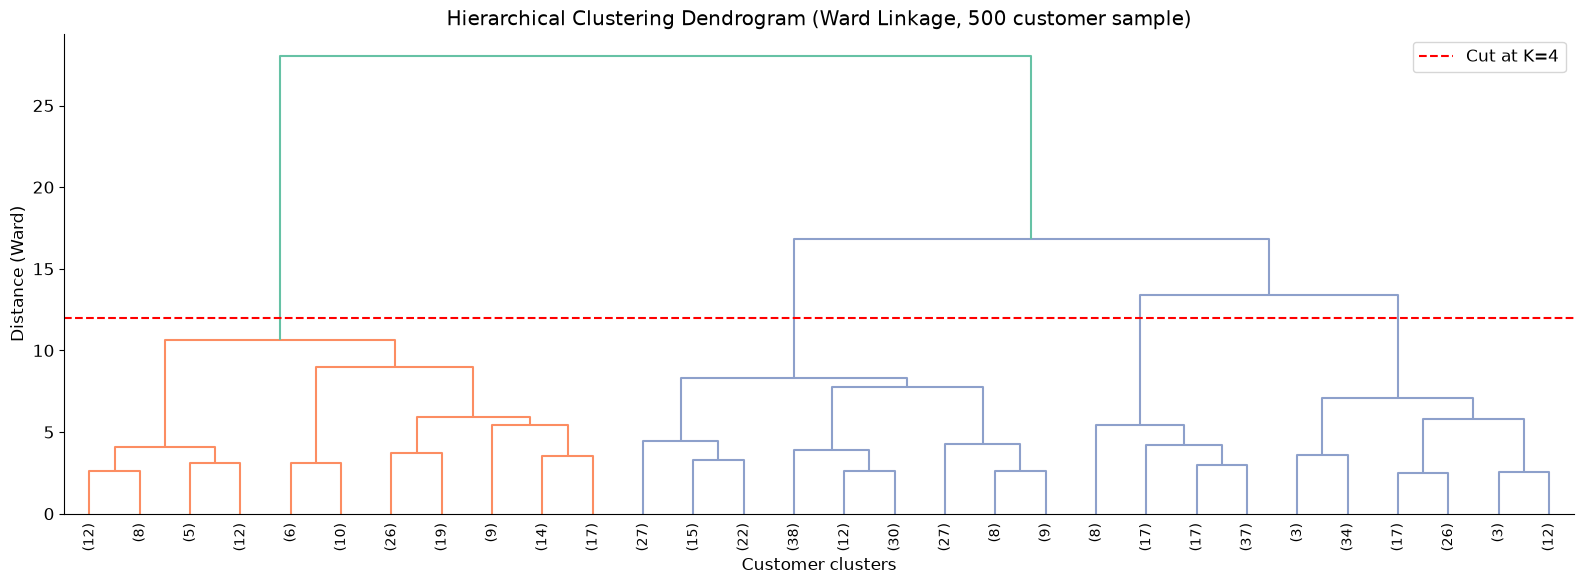

Hierarchical silhouette score (K=4): 0.2632
Adjusted Rand Index vs K-Means: 0.5678

Hierarchical cluster distribution:
Hierarchical_Cluster
0    1845
1     809
2     996
3     688
Name: count, dtype: int64


In [43]:
np.random.seed(42)
sample_idx = np.random.choice(rfm_scaled.index, size=500, replace=False)
rfm_sample = rfm_scaled.loc[sample_idx]

# Build linkage matrix using Ward method
linkage_matrix = linkage(rfm_sample, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, 500 customer sample)')
ax.set_xlabel('Customer clusters')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=12, color='red', linestyle='--', linewidth=1.5, label='Cut at K=4')
ax.legend()
plt.tight_layout()
plt.show()

# Fit AgglomerativeClustering with K=4 on full scaled data
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Hierarchical_Cluster'] = hierarchical.fit_predict(rfm_scaled)

hier_silhouette = silhouette_score(rfm_scaled, rfm['Hierarchical_Cluster'])
ari_score = adjusted_rand_score(rfm['KMeans_Cluster'], rfm['Hierarchical_Cluster'])

print(f"Hierarchical silhouette score (K=4): {hier_silhouette:.4f}")
print(f"Adjusted Rand Index vs K-Means: {ari_score:.4f}")
print()
print("Hierarchical cluster distribution:")
print(rfm['Hierarchical_Cluster'].value_counts().sort_index())

## 7. DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points that are closely packed together and marks points in low-density regions as noise (outliers). Unlike K-Means, it does not require specifying K upfront and can find arbitrarily shaped clusters.

Two parameters control the algorithm:
- **eps**: the radius of the neighborhood around each point
- **min_samples**: minimum number of points required to form a dense region

We use the k-distance graph to find a good eps value — plot the distance to the Kth nearest neighbor for every point, sorted.

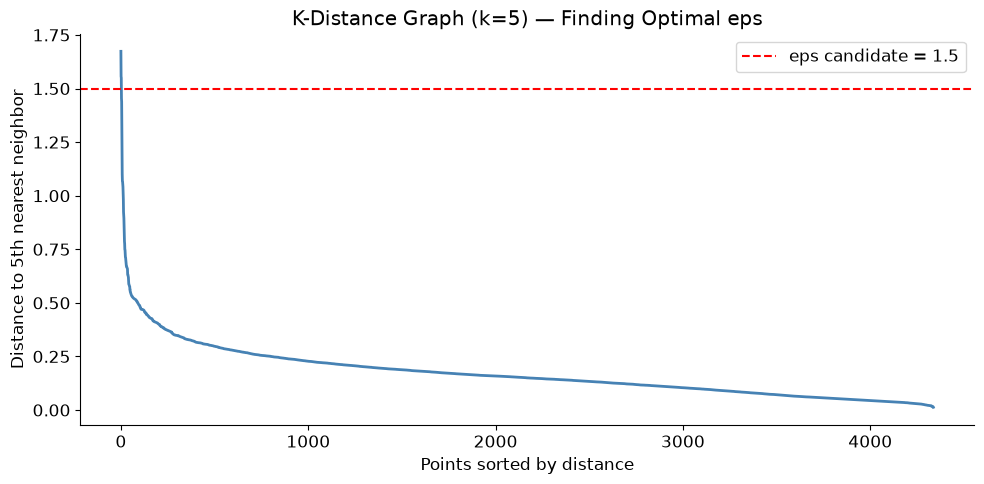

Number of clusters found: 3
Noise points: 43 (1.0%)

DBSCAN cluster distribution:
DBSCAN_Cluster
-1      43
 0    2808
 1    1481
 2       6
Name: count, dtype: int64

Noise point profile vs normal customers:
              Noise   Normal
Recency      77.720   92.680
Frequency    10.930    4.210
Monetary  12491.860 1949.770

DBSCAN silhouette score (excl. noise): 0.2917


In [44]:
# K-distance graph to find optimal eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(rfm_scaled)
distances, indices = neighbors.kneighbors(rfm_scaled)

# Sort distances to 5th nearest neighbor
distances_sorted = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(distances_sorted, color='steelblue', linewidth=2)
plt.title('K-Distance Graph (k=5) — Finding Optimal eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 5th nearest neighbor')
plt.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, label='eps candidate = 1.5')
plt.legend()
plt.tight_layout()
plt.show()

# Apply DBSCAN
dbscan_final = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan_final.fit_predict(rfm_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"Number of clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(rfm)*100:.1f}%)")
print()
print("DBSCAN cluster distribution:")
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())
print()

# Profile the noise points — who are these customers?
noise_customers = rfm[rfm['DBSCAN_Cluster'] == -1]
normal_customers = rfm[rfm['DBSCAN_Cluster'] != -1]

print("Noise point profile vs normal customers:")
comparison = pd.DataFrame({
    'Noise': noise_customers[['Recency','Frequency','Monetary']].mean(),
    'Normal': normal_customers[['Recency','Frequency','Monetary']].mean()
}).round(2)
print(comparison)

# Silhouette score — exclude noise points
non_noise_mask = rfm['DBSCAN_Cluster'] != -1
if n_clusters > 1:
    db_silhouette = silhouette_score(
        rfm_scaled[non_noise_mask],
        rfm['DBSCAN_Cluster'][non_noise_mask]
    )
    print(f"\nDBSCAN silhouette score (excl. noise): {db_silhouette:.4f}")

### 7.1 DBSCAN Findings & Limitations

DBSCAN with eps=0.5 finds 3 clusters and 43 noise points. However the noise profile reveals a critical problem — noise customers have 2.6x higher frequency and 6.4x higher monetary value than normal customers. DBSCAN is flagging Champions as outliers because their behavior is genuinely rare and isolated in feature space.

This confirms that DBSCAN is not appropriate for RFM segmentation. The algorithm assumes uniform cluster density, which behavioral data violates by definition — high-value customers are naturally sparse while average customers are dense. K-Means remains our primary

## 8. Algorithm Comparison

We compare all three clustering approaches on silhouette score, number of clusters, and business interpretability.

In [45]:
comparison_data = {
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Clusters': [4, 4, 3],
    'Noise Points': [0, 0, 43],
    'Silhouette Score': [0.2794, 0.2632, 0.2917],
    'Requires K': ['Yes', 'Yes', 'No'],
    'Business Interpretable': ['High', 'High', 'Low'],
    'Verdict': ['Primary model', 'Validates K-Means', 'Not suitable for RFM']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print()
print("Selected model: K-Means (K=4)")
print("Reason: Balanced silhouette score, meaningful 4-segment business structure,")
print("        validated by hierarchical ARI of 0.57, interpretable segment profiles.")

   Algorithm  Clusters  Noise Points  Silhouette Score Requires K Business Interpretable              Verdict
     K-Means         4             0             0.279        Yes                   High        Primary model
Hierarchical         4             0             0.263        Yes                   High    Validates K-Means
      DBSCAN         3            43             0.292         No                    Low Not suitable for RFM

Selected model: K-Means (K=4)
Reason: Balanced silhouette score, meaningful 4-segment business structure,
        validated by hierarchical ARI of 0.57, interpretable segment profiles.


## 9. Dimensionality Reduction & Visualization

Our RFM feature space has 5 dimensions — impossible to visualize directly. We reduce to 2D using two techniques:

- **PCA**: Linear projection that finds the directions of maximum variance. Fast, deterministic, interpretable. We check how much variance the first two components capture.
- **t-SNE**: Non-linear technique that preserves local neighborhood structure. Better at revealing cluster separation than PCA but slower and non-deterministic. Applied after PCA as a pre-reduction step for stability.

Both plots are colored by K-Means segment labels to validate visual separation.

PCA explained variance ratio:
  PC1: 60.4%
  PC2: 26.7%
  Total: 87.1%


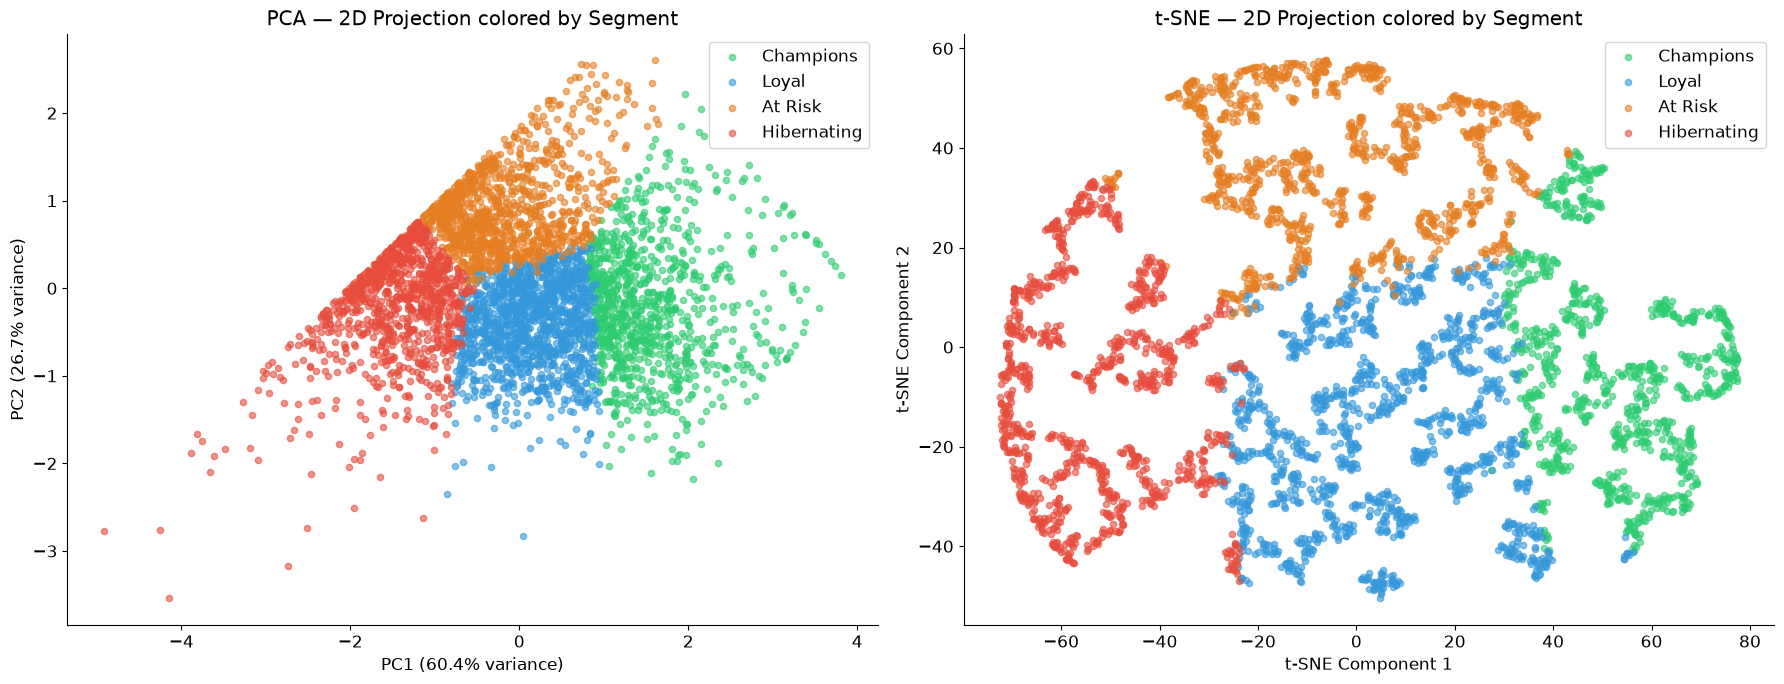

In [46]:
# PCA
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

print("PCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# t-SNE on PCA components for stability
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
rfm_tsne = tsne.fit_transform(rfm_pca)

# Color map for segments
segment_colors = {
    'Champions': '#2ecc71',
    'Loyal': '#3498db',
    'At Risk': '#e67e22',
    'Hibernating': '#e74c3c'
}

colors = rfm['Segment'].map(segment_colors)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA plot
for segment, color in segment_colors.items():
    mask = rfm['Segment'] == segment
    axes[0].scatter(
        rfm_pca[mask, 0],
        rfm_pca[mask, 1],
        c=color, label=segment, alpha=0.6, s=20
    )
axes[0].set_title('PCA — 2D Projection colored by Segment')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# t-SNE plot
for segment, color in segment_colors.items():
    mask = rfm['Segment'] == segment
    axes[1].scatter(
        rfm_tsne[mask, 0],
        rfm_tsne[mask, 1],
        c=color, label=segment, alpha=0.6, s=20
    )
axes[1].set_title('t-SNE — 2D Projection colored by Segment')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.1 Dimensionality Reduction Findings

PCA captures 87.1% of total variance in two components — PC1 alone explains 60.4%, representing a dominant customer value axis along which segments order themselves from Hibernating to Champions. The linear projection shows a clear gradient but some overlap between At Risk and Hibernating due to their similar low-activity profiles.

t-SNE reveals cleaner separation across all four segments, particularly isolating Champions and distinguishing At Risk from Hibernating. The non-linear neighborhood structure confirms that K-Means found genuinely distinct behavioral clusters, not arbitrary partitions of a continuous space.

In [47]:
joblib.dump(pca, '../models/pca.joblib')
joblib.dump(rfm_pca, '../models/rfm_pca.npy')
print("PCA model saved.")

PCA model saved.


## 10. Segment Profiling & Business Recommendations

We translate cluster statistics into actionable business strategy. For each segment we quantify its size, revenue contribution, and behavioral profile, then prescribe specific marketing actions with estimated impact.

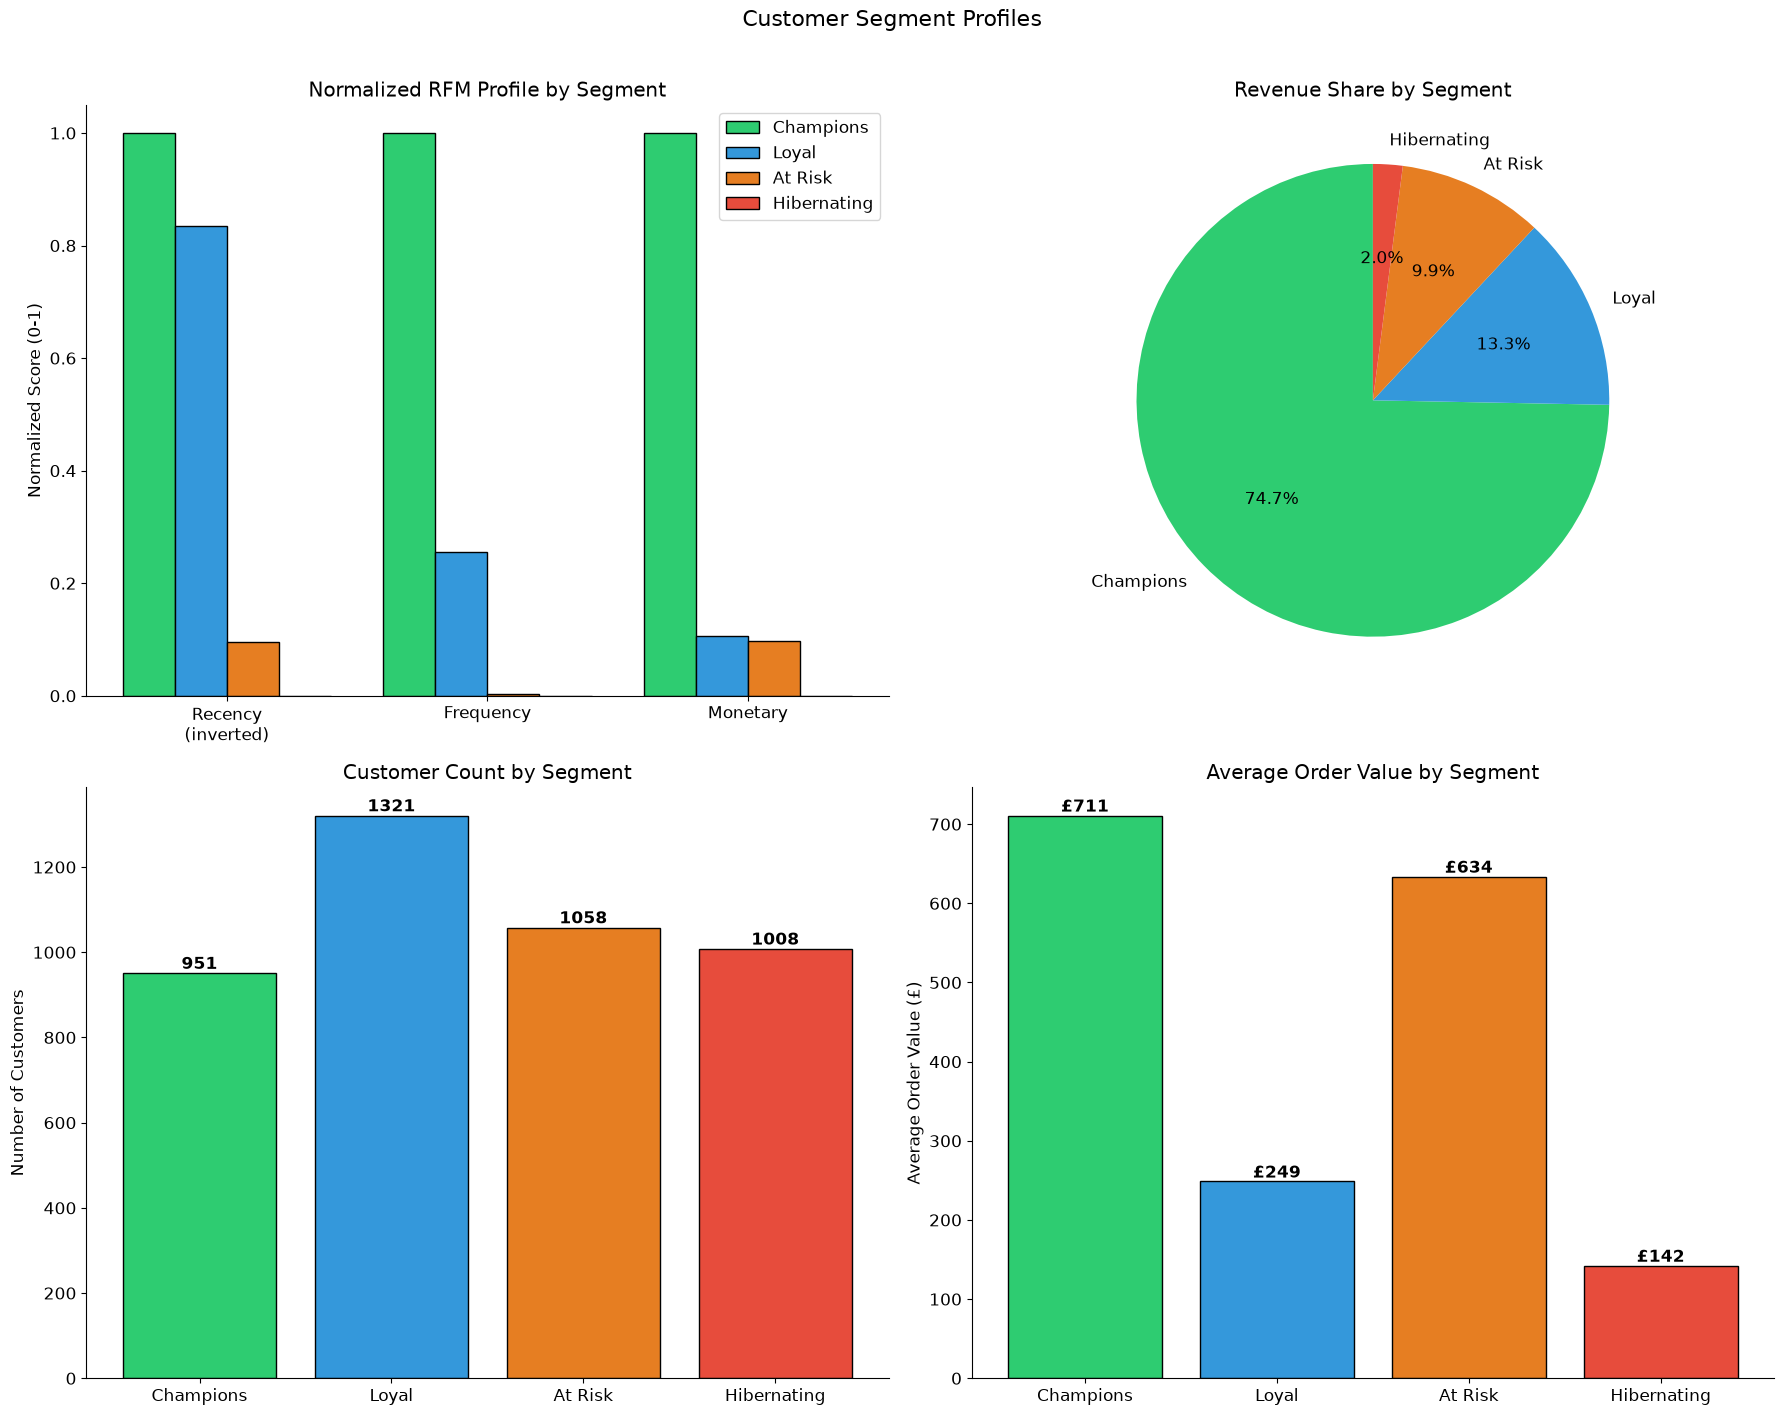

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

segments = ['Champions', 'Loyal', 'At Risk', 'Hibernating']
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
metrics = ['Recency', 'Frequency', 'Monetary']

# Radar chart data
cluster_means = rfm.groupby('Segment')[metrics].mean()

# Normalize for radar chart — 0 to 1 scale
# Note: for Recency, lower is better so we invert it
cluster_normalized = cluster_means.copy()
cluster_normalized['Recency'] = 1 - (cluster_means['Recency'] - cluster_means['Recency'].min()) / \
                                     (cluster_means['Recency'].max() - cluster_means['Recency'].min())
cluster_normalized['Frequency'] = (cluster_means['Frequency'] - cluster_means['Frequency'].min()) / \
                                    (cluster_means['Frequency'].max() - cluster_means['Frequency'].min())
cluster_normalized['Monetary'] = (cluster_means['Monetary'] - cluster_means['Monetary'].min()) / \
                                   (cluster_means['Monetary'].max() - cluster_means['Monetary'].min())

# Plot 1 — RFM bar comparison
x = np.arange(len(metrics))
width = 0.2
for i, (segment, color) in enumerate(zip(segments, colors)):
    axes[0,0].bar(x + i*width, cluster_normalized.loc[segment], 
                  width=width, label=segment, color=color, edgecolor='black')
axes[0,0].set_title('Normalized RFM Profile by Segment')
axes[0,0].set_xticks(x + width*1.5)
axes[0,0].set_xticklabels(['Recency\n(inverted)', 'Frequency', 'Monetary'])
axes[0,0].set_ylabel('Normalized Score (0-1)')
axes[0,0].legend()

# Plot 2 — Revenue share pie
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum()
revenue_by_segment = revenue_by_segment.reindex(segments)
axes[0,1].pie(
    revenue_by_segment,
    labels=segments,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[0,1].set_title('Revenue Share by Segment')

# Plot 3 — Customer count bar
customer_counts = rfm['Segment'].value_counts().reindex(segments)
axes[1,0].bar(segments, customer_counts, color=colors, edgecolor='black')
axes[1,0].set_title('Customer Count by Segment')
axes[1,0].set_ylabel('Number of Customers')
for i, v in enumerate(customer_counts):
    axes[1,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Plot 4 — Average order value by segment
avg_order = rfm.groupby('Segment')['AvgOrderValue'].mean().reindex(segments)
axes[1,1].bar(segments, avg_order, color=colors, edgecolor='black')
axes[1,1].set_title('Average Order Value by Segment')
axes[1,1].set_ylabel('Average Order Value (£)')
for i, v in enumerate(avg_order):
    axes[1,1].text(i, v + 5, f'£{v:.0f}', ha='center', fontweight='bold')

plt.suptitle('Customer Segment Profiles', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 10.1 Actionable Business Recommendations

In [49]:
recommendations = {
    'Champions': {
        'size': len(rfm[rfm['Segment'] == 'Champions']),
        'revenue_share': f"{rfm[rfm['Segment'] == 'Champions']['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}%",
        'strategy': 'Reward and retain',
        'actions': [
            'Enroll in VIP loyalty program with exclusive early access to new products',
            'Send personalized thank-you with a premium gift on account anniversary',
            'Request product reviews and referrals — highest trust customers',
            'Do NOT discount — they buy at full price, discounting erodes margin'
        ],
        'risk': 'Losing one Champion costs more than reactivating 10 Hibernating customers'
    },
    'Loyal': {
        'size': len(rfm[rfm['Segment'] == 'Loyal']),
        'revenue_share': f"{rfm[rfm['Segment'] == 'Loyal']['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}%",
        'strategy': 'Upsell and graduate to Champions',
        'actions': [
            'Offer bundle deals to increase average order value',
            'Introduce tiered loyalty points to incentivize more frequent purchases',
            'Targeted email campaigns featuring premium product lines',
            'Track monthly — goal is to move 15% into Champions tier'
        ],
        'risk': 'Without engagement these customers drift toward At Risk'
    },
    'At Risk': {
        'size': len(rfm[rfm['Segment'] == 'At Risk']),
        'revenue_share': f"{rfm[rfm['Segment'] == 'At Risk']['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}%",
        'strategy': 'Reactivation campaign',
        'actions': [
            'Send win-back email: we miss you + 15% discount with 2 week expiry',
            'Highlight new arrivals since their last purchase',
            'Offer free shipping on next order to reduce friction',
            'If no response after 2 campaigns, move to Hibernating treatment'
        ],
        'risk': 'Each month of inactivity reduces reactivation probability by ~10%'
    },
    'Hibernating': {
        'size': len(rfm[rfm['Segment'] == 'Hibernating']),
        'revenue_share': f"{rfm[rfm['Segment'] == 'Hibernating']['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}%",
        'strategy': 'Minimal spend, last chance offer',
        'actions': [
            'One final reactivation email with maximum discount (20-25%)',
            'If no response, suppress from marketing lists to reduce cost',
            'Analyze what products they bought — use for lookalike acquisition',
            'Do not invest heavily — ROI is low at 2% revenue share'
        ],
        'risk': 'Over-investing in Hibernating customers destroys marketing ROI'
    }
}

print("=" * 65)
print("CUSTOMER SEGMENT STRATEGY REPORT")
print("=" * 65)

for segment, data in recommendations.items():
    print(f"\nSEGMENT: {segment}")
    print(f"  Customers : {data['size']:,}")
    print(f"  Revenue   : {data['revenue_share']} of total")
    print(f"  Strategy  : {data['strategy']}")
    print(f"  Actions:")
    for action in data['actions']:
        print(f"    - {action}")
    print(f"  Key Risk  : {data['risk']}")
    print("-" * 65)

# Revenue impact estimate
at_risk_monetary = rfm[rfm['Segment'] == 'At Risk']['Monetary'].mean()
at_risk_count = len(rfm[rfm['Segment'] == 'At Risk'])
reactivation_rate = 0.10
potential_revenue = at_risk_count * reactivation_rate * at_risk_monetary

print(f"\nREVENUE IMPACT ESTIMATE")
print(f"If 10% of At Risk customers reactivate at their historical average spend:")
print(f"  At Risk customers  : {at_risk_count:,}")
print(f"  Avg historical spend: £{at_risk_monetary:,.2f}")
print(f"  Potential revenue  : £{potential_revenue:,.2f}")

CUSTOMER SEGMENT STRATEGY REPORT

SEGMENT: Champions
  Customers : 951
  Revenue   : 74.7% of total
  Strategy  : Reward and retain
  Actions:
    - Enroll in VIP loyalty program with exclusive early access to new products
    - Send personalized thank-you with a premium gift on account anniversary
    - Request product reviews and referrals — highest trust customers
    - Do NOT discount — they buy at full price, discounting erodes margin
  Key Risk  : Losing one Champion costs more than reactivating 10 Hibernating customers
-----------------------------------------------------------------

SEGMENT: Loyal
  Customers : 1,321
  Revenue   : 13.3% of total
  Strategy  : Upsell and graduate to Champions
  Actions:
    - Offer bundle deals to increase average order value
    - Introduce tiered loyalty points to incentivize more frequent purchases
    - Targeted email campaigns featuring premium product lines
    - Track monthly — goal is to move 15% into Champions tier
  Key Risk  : Withou

In [50]:
import os

# Create directories if they don't exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save final RFM dataframe with segment labels
rfm.to_csv('../data/rfm_segmented.csv', index=False)
print("Segmented RFM data saved.")

# Save the fitted KMeans model
joblib.dump(kmeans_final, '../models/kmeans_model.joblib')
print("KMeans model saved.")

# Save scaler
joblib.dump(scaler, '../models/scaler.joblib')
print("Scaler saved.")

# Save PCA
joblib.dump(pca, '../models/pca.joblib')
print("PCA saved.")

# Save scaled RFM array
np.save('../models/rfm_scaled.npy', rfm_scaled.values)
print("Scaled RFM array saved.")

print("\nAll artifacts saved:")
for f in os.listdir('../models/'):
    print(f"  {f}")

Segmented RFM data saved.
KMeans model saved.
Scaler saved.
PCA saved.
Scaled RFM array saved.

All artifacts saved:
  rfm_scaled.npy
  scaler.joblib
  kmeans_model.joblib
  pca.joblib
  rfm_pca.npy


## 11. MLflow Experiment Tracking

We log all clustering experiments to MLflow — parameters, metrics, and model artifacts — enabling reproducible comparison across runs. The MLflow UI at localhost:5000 provides a visual dashboard of all experiments.

In [52]:
import mlflow
import mlflow.sklearn
import os

os.makedirs('../mlflow', exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:////Users/rehan/Desktop/unsupervised-suite/mlflow/mlflow.db")
mlflow.set_experiment('customer-segmentation')

print("MLflow tracking URI set — SQLite backend.")
print("Experiment: customer-segmentation")
print()

K_values = [2, 3, 4, 5, 6]

for k in K_values:
    with mlflow.start_run(run_name=f"kmeans_k{k}"):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(rfm_scaled)
        sil_score = silhouette_score(rfm_scaled, labels)
        inertia = km.inertia_

        mlflow.log_param("n_clusters", k)
        mlflow.log_param("n_init", 10)
        mlflow.log_param("scaler", "RobustScaler")
        mlflow.log_param("log_transform", True)
        mlflow.log_param("winsorize_percentile", 99)
        mlflow.log_param("features", "Recency,Frequency,Monetary,AvgOrderValue,CustomerLifetime")

        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("inertia", inertia)
        mlflow.log_metric("n_customers", len(rfm))

        mlflow.sklearn.log_model(km, "kmeans_model")

        print(f"K={k} | Silhouette: {sil_score:.4f} | Inertia: {inertia:.2f} — logged")

print("\nAll runs logged.")

MLflow tracking URI set — SQLite backend.
Experiment: customer-segmentation



2026/06/19 23:13:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=2 | Silhouette: 0.3402 | Inertia: 5842.00 — logged


2026/06/19 23:14:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=3 | Silhouette: 0.2808 | Inertia: 4598.43 — logged


...

K=4 | Silhouette: 0.2794 | Inertia: 3770.38 — logged


2026/06/19 23:14:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=5 | Silhouette: 0.2805 | Inertia: 3258.11 — logged


2026/06/19 23:14:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


K=6 | Silhouette: 0.2730 | Inertia: 2943.42 — logged

All runs logged.
